In [ ]:
# Геометрические параметры
h1 = 1e-3       # глубина залегания неоднородности (м)
r1 = 3e-3       # радиус неоднородности (м)
a0 = 30e-3      # половина расстояния между токовыми электродами (м)
b10 = 15e-3     # половина расстояния между потенциалными электродами (слева) (м)
br0 = 15e-3     # половина расстояния между потенциалными электродами (справа) (м)

# Электрические параметры
rho1 = 7.74    # удельное сопротивление среды, в которой находится неоднородность (Ом·м)
rho2 = 1.0      # удельное сопротивление неоднородности (Ом·м)

# Смещения сферы (координаты центра)
x0 = 0.01       # смещение сферы перпендикулярно оси сборки (м)
y0 = 1e-3       # смещение сферы вдоль оси сборки (м)

N=100


In [ ]:
import numpy as np
from scipy.special import legendre


In [ ]:
def rM(r1, h1, b, x, y):
    return np.sqrt((r1 + h1)**2 + (b - y)**2 + x**2)

def rN(r1, h1, b, x, y):
    return np.sqrt((r1 + h1)**2 + (b + y)**2 + x**2)

def r0A(r1, h1, a, x, y):
    return np.sqrt((r1 + h1)**2 + (a - y)**2 + x**2)

def r0B(r1, h1, a, x, y):
    return np.sqrt((r1 + h1)**2 + (a + y)**2 + x**2)

In [ ]:
def cos_theta_AM(r1, h1, a, b, x, y):
    RA = r0A(r1, h1, a, x, y)
    RM = rM(r1, h1, b, x, y)
    return (RA**2 + RM**2 - (a - b)**2) / (2 * RA * RM)

def cos_theta_AN(r1, h1, a, b, x, y):
    RA = r0A(r1, h1, a, x, y)
    RN = rN(r1, h1, b, x, y)
    return (RA**2 + RN**2 - (a + b)**2) / (2 * RA * RN)

def cos_theta_BM(r1, h1, a, b, x, y):
    RB = r0B(r1, h1, a, x, y)
    RM = rM(r1, h1, b, x, y)
    return (RB**2 + RM**2 - (a + b)**2) / (2 * RB * RM)

def cos_theta_BN(r1, h1, a, b, x, y):
    RB = r0B(r1, h1, a, x, y)
    RN = rN(r1, h1, b, x, y)
    return (RB**2 + RN**2 - (a - b)**2) / (2 * RB * RN)

In [ ]:
def dZ_component(rho1, rho2, a, b, r1, h1, x, y,
                 r0_func,      # r0A или r0B
                 r_inner_func, # rM  или rN
                 cos_theta_func,
                 N):
    r0 = r0_func(r1, h1, a, x, y)
    S = 0.0
    for n in range(N + 1):
        r_in = r_inner_func(r1, h1, b, x, y)
        cosθ = cos_theta_func(r1, h1, a, b, x, y)
        Pn  = legendre(n)(cosθ)
        coef = n * (rho2 - rho1) / ((n + 1) * rho2 + n * rho1)
        S   += (r1 / r_in)**(n + 1) * (r1 / r0)**n * coef * Pn
    return rho1 / (np.pi * r0) * S


In [ ]:
def dZ_total(rho1, rho2, a, bl, br, r1, h1, x, y, N):
    dz_am = dZ_component(rho1, rho2, a, bl, r1, h1, x, y,
                         r0A, rM, cos_theta_AM, N)
    print(f"dz_am = {dz_am:.6e} Ом")
    dz_an = dZ_component(rho1, rho2, a, br, r1, h1, x, y,
                         r0A, rN, cos_theta_AN, N)
    print(f"dz_an = {dz_an:.6e} Ом")
    dz_bm = dZ_component(rho1, rho2, a, bl, r1, h1, x, y,
                         r0B, rM, cos_theta_BM, N)
    print(f"dz_bm = {dz_bm:.6e} Ом")
    dz_bn = dZ_component(rho1, rho2, a, br, r1, h1, x, y,
                         r0B, rN, cos_theta_BN, N)
    print(f"dz_bn = {dz_bn:.6e} Ом")
    return dz_am - dz_an + dz_bn - dz_bm


def Zbase(rho1, rho2, a, bl, br, r1, h1, x, y, N):
    term = (rho1 * 2 * bl) / (np.pi * (a**2 - bl**2))
    dz = dZ_total(rho1, rho2, a, bl, br, r1, h1, x, y, N)
    return term + dz

# Проверим результат
dz = dZ_total(rho1, rho2, a0, br0, b10, r1, h1, x0, y0, N)
print(f"dZ_total = {dz:.6e} Ом")


Z = Zbase(rho1, rho2, a0, br0, b10, r1, h1, x0, y0, N)
print(f"Zbase = { Z:.6e} Ом")


In [ ]:
import numpy as np

def dZ(p1, p2, a, b, r1, h1, x, y):
    return (p1 - p2) * (1 / (np.pi * (a**2 - b**2))) * np.exp(-((x**2 + y**2) / (a**2 - b**2)))

def Zbase(p1, p2, a, b, r1, h1, x, y):
    return (p1 * 2 * b) / (np.pi * (a**2 - b**2)) + dZ(p1, p2, a, b, r1, h1, x, y)

def ZbaseS(p1, p2, a, b, r1, h1, x, y):
    return (p1 * 2 * b) / (np.pi * (a**2 - b**2)) + dZ(p1, p2, a, b, r1, h1, x, y)


def ro1Base1(h, rad, zbase, a, b):
    dro = 0.2
    ro = 0
    for i in range(-10, 11):
        zb1 = Zbase(5 + dro * i, 1.35, a, b, rad, h, 0, 0)
        zb2 = Zbase(5 + dro * (i + 1), 1.35, a, b, rad, h, 0, 0)
        if (zb2 > zbase) and (zb1 < zbase):
            ro = 5 + i * dro
    return ro

def ro1BaseAC(h, rad, zbase, a, b):
    dro = 0.1
    ro = 0
    for i in range(-20, 21):
        zb1 = Zbase(5 + dro * i, 1.35, a, b, rad, h, 0, 0)
        zb2 = Zbase(5 + dro * (i + 1), 1.35, a, b, rad, h, 0, 0)
        if (zb2 > zbase) and (zb1 < zbase):
            ro = 5 + i * dro
    return ro

def ro1BaseAC_y(h, rad, zbase, a, b, y):
    dro = 0.1
    ro = 0
    for i in range(-40, 61):
        zb1 = Zbase(5 + dro * i, 1.35, a, b, rad, h, 0, y)
        zb2 = Zbase(5 + dro * (i + 1), 1.35, a, b, rad, h, 0, y)
        if (zb2 > zbase) and (zb1 < zbase):
            ro = 5 + i * dro
    return ro

def droFL(dz):
    return dz * np.pi * (0.05**2 - 0.025**3) / 0.025

def dR(dZ_val, dRo, p1, h, rad, a, b, y):
    dr = 0.0001
    dRR = 0
    for i in range(151):
        zb1 = Zbase(p1 - dRo, 1.35, a, b, rad, h, 0, y) - Zbase(p1 - dRo - dr * i, 1.35, a, b, rad, h, 0, y)
        zb2 = Zbase(p1 - dRo, 1.35, a, b, rad, h, 0, y) - Zbase(p1 - dRo - dr * (i + 1), 1.35, a, b, rad, h, 0, y)
        if (zb2 < dZ_val) and (zb1 > dZ_val):
            dRR = i * dr
    return dRR

def dR_Xch(dZ_val, dRo, dy, h, rad, zbase, a, b, y):
    return dR(-dZ_val, dRo, ro1BaseAC_y(h, rad, zbase, a, b, y + dy), h, rad, a, b, y)


# Проверим результат
dz = dZ_total(rho1, rho2, a0, br0, b10, r1, h1, x0, y0, N)
print(f"dZ_total = {dz:.6e} Ом")


Z = Zbase(rho1, rho2, a0, b10, r1, h1, x0, y0)
print(f"Zbase = { Z:.6e} Ом")


In [9]:
# @title 2D график
import numpy as np
import pandas as pd
import altair as alt

# Функция Zbase
def dZ(p1, p2, a, b, r1, h1, x, y):
    return (p1 - p2) * (1 / (np.pi * (a**2 - b**2))) * np.exp(-((x**2 + y**2) / (a**2 - b**2)))

def Zbase(p1, p2, a, b, r1, h1, x, y):
    return (p1**2 - b**1) / (np.pi * (a**2 - b**2)) + dZ(p1, p2, a, b, r1, h1, x, y)

# Параметры
p1 = 1.35
p2 = 0.05
a = 0.025
b = 0.046
r1 = 0.02
h1 = 0
y = 0  # фиксированный y

# Генерация данных по оси x
x_vals = np.linspace(-0.1, 0.1, 400)
z_vals = [Zbase(p1, p2, a, b, r1, h1, x, y) for x in x_vals]

# DataFrame для Altair
df = pd.DataFrame({
    'x': x_vals,
    'Zbase': z_vals
})

# Построение графика
chart = alt.Chart(df).mark_line().encode(
    x=alt.X('x', title='x'),
    y=alt.Y('Zbase', title='Zbase(p1, p2, a, b, r1, h1, x, y=0)')
).properties(
    title='Профиль функции Zbase по оси x при y=0',
    width=600,
    height=400
)

chart


alt.Chart(...)

In [10]:
# @title 2D график
import numpy as np
import pandas as pd
import altair as alt

# Функция dZ и Zbase
def dZ(p1, p2, a, b, r1, h1, x, y):
    return (p1 - p2) / (np.pi * (a**2 - b**2)) * np.exp(-(x**2 + y**2) / (a**2 - b**2))

def Zbase(p1, p2, a, b, r1, h1, x, y):
    return (p1**2 - b) / (np.pi * (a**2 - b**2)) + dZ(p1, p2, a, b, r1, h1, x, y)

# Параметры
p1 = 1.0
p2 = 0.8
a = 0.037
b = 0.025
r1 = 0.01
h1 = 0
x0 = 0.0  # фиксированный x

# Диапазон y
y_vals = np.linspace(-0.025, 0.025, 400)
z_vals = [Zbase(p1, p2, a, b, r1, h1, x0, y) for y in y_vals]

# DataFrame
df = pd.DataFrame({
    'y': y_vals,
    'Zbase': z_vals
})

# Altair график
chart = alt.Chart(df).mark_line(color='blue').encode(
    x=alt.X('y', title='y'),
    y=alt.Y('Zbase', title='Zbase(p1, p2, a, b, r1, h1, x0, y)')
).properties(
    title='Срез Zbase по оси y при x = x0',
    width=600,
    height=400
)

chart


alt.Chart(...)

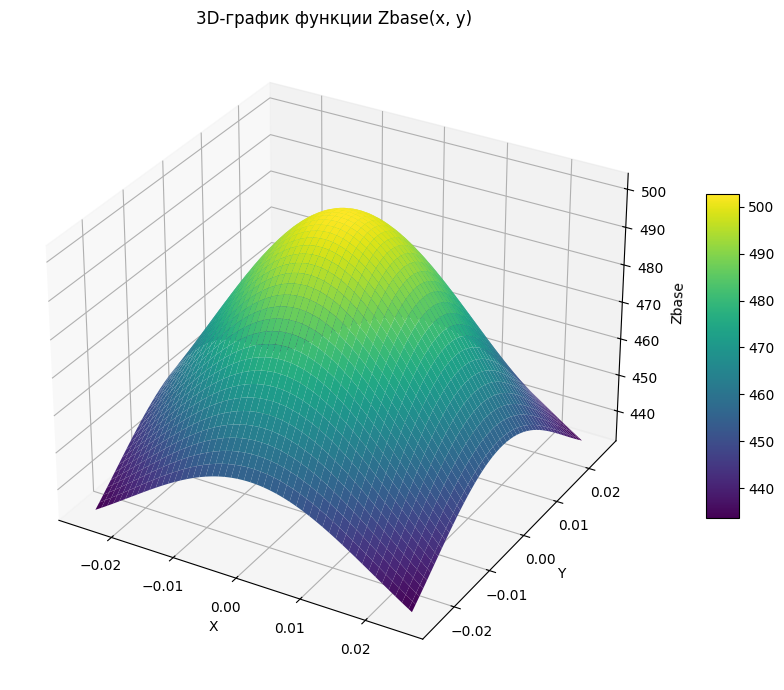

In [11]:
# @title 3D график

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Определение dZ и Zbase
def dZ(p1, p2, a, b, r1, h1, x, y):
    return (p1 - p2) / (np.pi * (a**2 - b**2)) * np.exp(-(x**2 + y**2) / (a**2 - b**2))

def Zbase(p1, p2, a, b, r1, h1, x, y):
    return (p1**2 - b) / (np.pi * (a**2 - b**2)) + dZ(p1, p2, a, b, r1, h1, x, y)

# Параметры
p1 = 1.0
p2 = 0.8
a = 0.037
b = 0.025
r1 = 0.01
h1 = 0

# Сетка x и y
x_vals = np.linspace(-0.025, 0.025, 100)
y_vals = np.linspace(-0.025, 0.025, 100)
X, Y = np.meshgrid(x_vals, y_vals)

# Расчёт Z
Z = Zbase(p1, p2, a, b, r1, h1, X, Y)

# Построение графика
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(X, Y, Z, cmap='viridis')

ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Zbase")
ax.set_title("3D-график функции Zbase(x, y)")
fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10)

plt.tight_layout()
plt.show()


In [12]:
# # @title Оптимизированная (кодом) функция рассчёта dZ и Z_base
# import numpy as np
# from scipy.special import legendre

# # --- Геометрические параметры ---
# h1 = 1e-3       # Глубина залегания неоднородности (м)
# r1 = 3e-3       # Радиус неоднородности (м)
# a0 = 30e-3      # Половина расстояния между токовыми электродами (м)
# b10 = 15e-3     # Половина расстояния между потенциалными электродами (слева) (м)
# br0 = 15e-3     # Половина расстояния между потенциалными электродами (справа) (м)

# # --- Электрические параметры ---
# rho1 = 0.774    # Удельное сопротивление среды (Ом·м)
# rho2 = 1.0      # Удельное сопротивление неоднородности (Ом·м)

# # --- Смещения центра неоднородности ---
# x0 = 0.01       # Смещение по X (м)
# y0 = 1e-3       # Смещение по Y (м)


# # --- Вспомогательные функции для расстояний ---
# def r0A(r1, h1, a, x, y):
#     return np.sqrt((r1 + h1)**2 + (a - y)**2 + x**2)

# def r0B(r1, h1, b, x, y):
#     return np.sqrt((r1 + h1)**2 + (b - y)**2 + x**2)

# def rM(r1, h1, b, x, y):
#     return np.sqrt((r1 + h1)**2 + (b - y)**2 + x**2)

# def rN(r1, h1, a, x, y):
#     return np.sqrt((r1 + h1)**2 + (a - y)**2 + x**2)


# # --- Вспомогательные функции для косинусов углов ---
# def cos_theta_AM(r1, h1, a, b, x, y):
#     rA = r0A(r1, h1, a, x, y)
#     rM_ = rM(r1, h1, b, x, y)
#     return (rA**2 + rM_**2 - (a - b)**2) / (2 * rA * rM_)

# def cos_theta_AN(r1, h1, a, b, x, y):
#     rA = r0A(r1, h1, a, x, y)
#     rN_ = rN(r1, h1, b, x, y)
#     return (rA**2 + rN_**2 - (a + b)**2) / (2 * rA * rN_)

# def cos_theta_BM(r1, h1, a, b, x, y):
#     rB = r0B(r1, h1, a, x, y)
#     rM_ = rM(r1, h1, b, x, y)
#     return (rB**2 + rM_**2 - (a + b)**2) / (2 * rB * rM_)

# def cos_theta_BN(r1, h1, a, b, x, y):
#     rB = r0B(r1, h1, a, x, y)
#     rN_ = rN(r1, h1, b, x, y)
#     return (rB**2 + rN_**2 - (a - b)**2) / (2 * rB * rN_)


# # --- Расчёт компоненты dZ ---
# def dZ_component(rho1, rho2, a, b, r1, h1, x, y, r_func, cos_func, N=100):
#     r_val = r_func(r1, h1, a, x, y)
#     cos_val = cos_func(r1, h1, a, b, x, y)
#     sum_value = 0
#     for n in range(N + 1):
#         Pn = legendre(n)
#         factor = ((r1 / r_val)**(n + 1)) * (rho2 - rho1) / ((n + 1) * rho1 + n * rho2)
#         sum_value += factor * Pn(cos_val)
#     return rho1 / (np.pi * r_val) * sum_value


# # --- Общая функция ---
# def dZ_total(rho1, rho2, a, b, r1, h1, x, y):
#     dz_am = dZ_component(rho1, rho2, a, b,  r1, h1, x, y, r0A, cos_theta_AM)
#     dz_an = dZ_component(rho1, rho2, a, -b, r1, h1, x, y, r0A, cos_theta_AN)
#     dz_bm = dZ_component(rho1, rho2, a, -b, r1, h1, x, y, r0B, cos_theta_BM)
#     dz_bn = dZ_component(rho1, rho2, a, b,  r1, h1, x, y, r0B, cos_theta_BN)
#     return dz_am + dz_an - dz_bm - dz_bn

# # Проверим результат
# dz = dZ_total(rho1, rho2, a0, b10, r1, h1, x0, y0)
# print(f"dZ_total = {dz:.6e} Ом")

# def Zbase(rho1, rho2, a0, b10, r1, h1, x0, y0):
#     return (rho1**2 - b10) / (np.pi * (a0**2 - b10**2)) + dZ_total(rho1, rho2, a0, b10, r1, h1, x0, y0)

# Z = Zbase(rho1, rho2, a0, b10, r1, h1, x0, y0)
# print(f"Zbase = { Z:.6e} Ом")



In [13]:

import numpy as np
from SALib.sample import morris as morris_sampler
from SALib.analyze import morris as morris_analyzer
from SALib.sample import saltelli
from SALib.analyze import sobol
from SALib.sample import fast_sampler
from SALib.analyze import fast
import matplotlib.pyplot as plt

# 🎯 Константы



def model(X):
    # X — матрица Nx4
    results = []
    for row in X:
        r1, h1, x0, y0 = row
        results.append(Zbase(p1, p2, a, b, r1, h1, x0, y0))
    return np.array(results)

# 🔢 Диапазоны параметров
problem = {
    'num_vars': 4,
    'names': ['r1', 'h1', 'x0', 'y0'],
    'bounds': [[0.01, 0.1], [0.0005, 0.025], [-0.05, 0.05], [-0.05, 0.05]]
}




# param_values = morris_sampler.sample(problem, N=100, num_levels=4)
# Y = model(param_values)

# Si = morris_analyzer.analyze(problem, param_values, Y, conf_level=0.95, print_to_console=True)

# # 📈 Визуализация
# plt.figure(figsize=(8, 5))
# plt.scatter(Si['mu_star'], Si['sigma'], s=100)
# for i, name in enumerate(problem['names']):
#     plt.text(Si['mu_star'][i], Si['sigma'][i], name, fontsize=12)
# plt.xlabel('mu* (влияние)')
# plt.ylabel('sigma (взаимодействие)')
# plt.title('Метод Морриса')
# plt.grid(True)
# plt.show()


ModuleNotFoundError: No module named 'SALib'

In [ ]:
test_inputs = morris_sampler.sample(problem, N=1000, num_levels=4)
test_outputs = model(test_inputs)
print("min:", np.min(test_outputs))
print("max:", np.max(test_outputs))
print("std:", np.std(test_outputs))

In [ ]:
# 📌 Метод Соболя
param_values = saltelli.sample(problem, N=1000, calc_second_order=True)
Y = model(param_values)

Si = sobol.analyze(problem, Y, calc_second_order=True, print_to_console=True)

# 📈 Визуализация первого порядка
plt.figure(figsize=(8, 5))
plt.bar(problem['names'], Si['S1'], yerr=Si['S1_conf'], capsize=5)
plt.ylabel('S1 (первичный индекс)')
plt.title('Метод Соболя — первый порядок')
plt.grid(True)
plt.show()


In [ ]:
# 📌 Метод FAST
param_values = fast_sampler.sample(problem, N=1000)
Y = model(param_values)

Si = fast.analyze(problem, Y, print_to_console=True)

# 📈 Визуализация
plt.figure(figsize=(8, 5))
plt.bar(problem['names'], Si['S1'], yerr=Si['S1_conf'], capsize=5)
plt.ylabel('S1 (первичный индекс)')
plt.title('Метод FAST')
plt.grid(True)
plt.show()
